# MedFT - LoRA / QLoRA Fine-Tuning of a Medical Vision-Language Model

Adapts `Qwen2.5-VL-7B-Instruct` to chest X-ray report generation with parameter-efficient fine-tuning (LoRA/QLoRA), and quantifies the gain over zero-shot prompting of the exact same base model.

---

### What this notebook does

1. Load `Qwen2.5-VL-7B-Instruct` **once**, in 4-bit (QLoRA).
2. Evaluate it zero-shot on a held-out test split - the **before** number.
3. Attach a LoRA adapter and supervise-fine-tune it on the OpenI training split.
4. Evaluate the *same* model, on the *same* test cases, with the adapter enabled - the **after** number.
5. Compare: NLP metrics, training loss, qualitative examples, latency/memory.

The research question is not "can a VLM write a radiology report" - zero-shot models already can. It's **how much does supervised, parameter-efficient adaptation actually buy you**, measured rather than assumed.

In [1]:
!pip install -q \
    peft \
    bitsandbytes \
    accelerate \
    evaluate \
    bert-score \
    rouge-score \
    sacrebleu \
    pycocoevalcap \
    seaborn \
    rich

print("Packages installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 5.3 MB/s eta 0:00:00
Packages installed.


## Step 1 - Configuration

In [2]:
from pathlib import Path

CFG = {
    # data
    "data_dir": "/kaggle/input/datasets/raddar/chest-xrays-indiana-university",
    "output_dir": "/kaggle/working/outputs",
    "frontal_only": True,
    "max_train_samples": 800,
    "seed": 42,

    # model
    "model_id": "Qwen/Qwen2.5-VL-7B-Instruct",
    "min_pixels": 256 * 28 * 28,
    "max_pixels": 768 * 28 * 28,
    "max_image_side": 1024,

    # LoRA / QLoRA
    "lora_r": 16,
    "lora_alpha": 32,
    "lora_dropout": 0.05,
    "lora_target_modules": ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],

    # training
    "num_train_epochs": 2,
    "learning_rate": 2e-4,
    "train_batch_size": 1,
    "grad_accum_steps": 8,
    "logging_steps": 5,

    # generation
    "max_new_tokens": 250,
    "num_eval_samples": 100,
    "bertscore_model": "roberta-large",
}

Path(CFG["output_dir"]).mkdir(parents=True, exist_ok=True)
CFG

{'data_dir': '/kaggle/input/datasets/raddar/chest-xrays-indiana-university',
 'output_dir': '/kaggle/working/outputs',
 'frontal_only': True,
 'max_train_samples': 800,
 'seed': 42,
 'model_id': 'Qwen/Qwen2.5-VL-7B-Instruct',
 'min_pixels': 200704,
 'max_pixels': 602112,
 'max_image_side': 1024,
 'lora_r': 16,
 'lora_alpha': 32,
 'lora_dropout': 0.05,
 'lora_target_modules': ['q_proj',
  'k_proj',
  'v_proj',
  'o_proj',
  'gate_proj',
  'up_proj',
  'down_proj'],
 'num_train_epochs': 2,
 'learning_rate': 0.0002,
 'train_batch_size': 1,
 'grad_accum_steps': 8,
 'logging_steps': 5,
 'max_new_tokens': 250,
 'num_eval_samples': 100,
 'bertscore_model': 'roberta-large'}

## Step 2 - (Optional) authenticate with HuggingFace

In [3]:
import os

try:
    from kaggle_secrets import UserSecretsClient
    os.environ["HF_TOKEN"] = UserSecretsClient().get_secret("HF_TOKEN")
    print("HF_TOKEN loaded from Kaggle Secrets.")
except Exception:
    print("No HF_TOKEN secret found - continuing with anonymous (rate-limited) downloads.")

HF_TOKEN loaded from Kaggle Secrets.


## Step 3 - Verify the GPU

In [4]:
import torch

assert torch.cuda.is_available(), "No GPU found - enable GPU in notebook settings."
gpu = torch.cuda.get_device_properties(0)
print(f"GPU:  {gpu.name}")
print(f"VRAM: {gpu.total_memory / 1e9:.1f} GB")
print(f"Compute capability: {gpu.major}.{gpu.minor}")

GPU:  Tesla T4
VRAM: 15.6 GB
Compute capability: 7.5


## Step 4 - Dataset: OpenI IU Chest X-Ray

In [5]:
import random
import pandas as pd
from pathlib import Path
from PIL import Image


class OpenIDataset:
    """Minimal OpenI IU X-Ray loader for the Kaggle CSV distribution - no external deps beyond pandas/PIL."""

    SPLIT_RATIOS = {"train": 0.80, "val": 0.10, "test": 0.10}

    def __init__(self, data_dir, seed=42, frontal_only=True):
        self.data_dir = Path(data_dir)
        self.seed = seed
        self.samples = self._load(frontal_only)

    def _load(self, frontal_only):
        reports_df = pd.read_csv(self.data_dir / "indiana_reports.csv")
        reports_df = reports_df.dropna(subset=["findings", "impression"], how="all")
        proj_df = pd.read_csv(self.data_dir / "indiana_projections.csv")

        images_dir = self.data_dir / "images" / "images_normalized"
        if not images_dir.exists():
            images_dir = self.data_dir / "images"

        samples = []
        for _, row in reports_df.iterrows():
            uid = str(row.get("uid", ""))
            findings = str(row["findings"]).strip() if pd.notna(row.get("findings")) else ""
            impression = str(row["impression"]).strip() if pd.notna(row.get("impression")) else ""
            parts = []
            if findings:
                parts.append(f"FINDINGS: {findings}")
            if impression:
                parts.append(f"IMPRESSION: {impression}")
            report = " ".join(parts)
            if not report:
                continue

            matched = proj_df[proj_df["uid"].astype(str) == uid]
            proj_rows = matched.to_dict("records") if len(matched) else [{"filename": row.get("filename", ""), "projection": ""}]

            for proj in proj_rows:
                proj_type = str(proj.get("projection", "")).strip()
                if frontal_only and proj_type not in ("Frontal", "PA", "AP", ""):
                    continue
                fname = str(proj.get("filename", "")).strip()
                if not fname:
                    continue
                img_path = images_dir / fname
                if not img_path.exists():
                    continue
                samples.append({
                    "id": f"{uid}_{Path(fname).stem}",
                    "image_path": img_path,
                    "report": report,
                    "projection": proj_type,
                })
        return samples

    def get_split(self, split):
        rng = random.Random(self.seed)
        indices = list(range(len(self.samples)))
        rng.shuffle(indices)
        n = len(indices)
        n_train = int(n * self.SPLIT_RATIOS["train"])
        n_val = int(n * self.SPLIT_RATIOS["val"])
        ranges = {
            "train": indices[:n_train],
            "val": indices[n_train:n_train + n_val],
            "test": indices[n_train + n_val:],
        }
        return [self.samples[i] for i in ranges[split]]

    def __len__(self):
        return len(self.samples)


def load_image(sample):
    return Image.open(sample["image_path"]).convert("RGB")

Total samples: 3794
Train: 800 (of 3035 available, capped by max_train_samples)  |  Test: 380
Planned SFT steps: 1600 (800 samples x 2 epochs)

Sample ID: 2100_2100_IM-0731-1001.dcm
Report:
FINDINGS: The heart size and mediastinal contours appear within normal limits. Atherosclerotic calcification of the aorta. No focal airspace consolidation, pleural effusions or pneumothorax. Questionable thin-walled cavitary lesion in the right lower lobe, only seen on the AP view and may represent ...


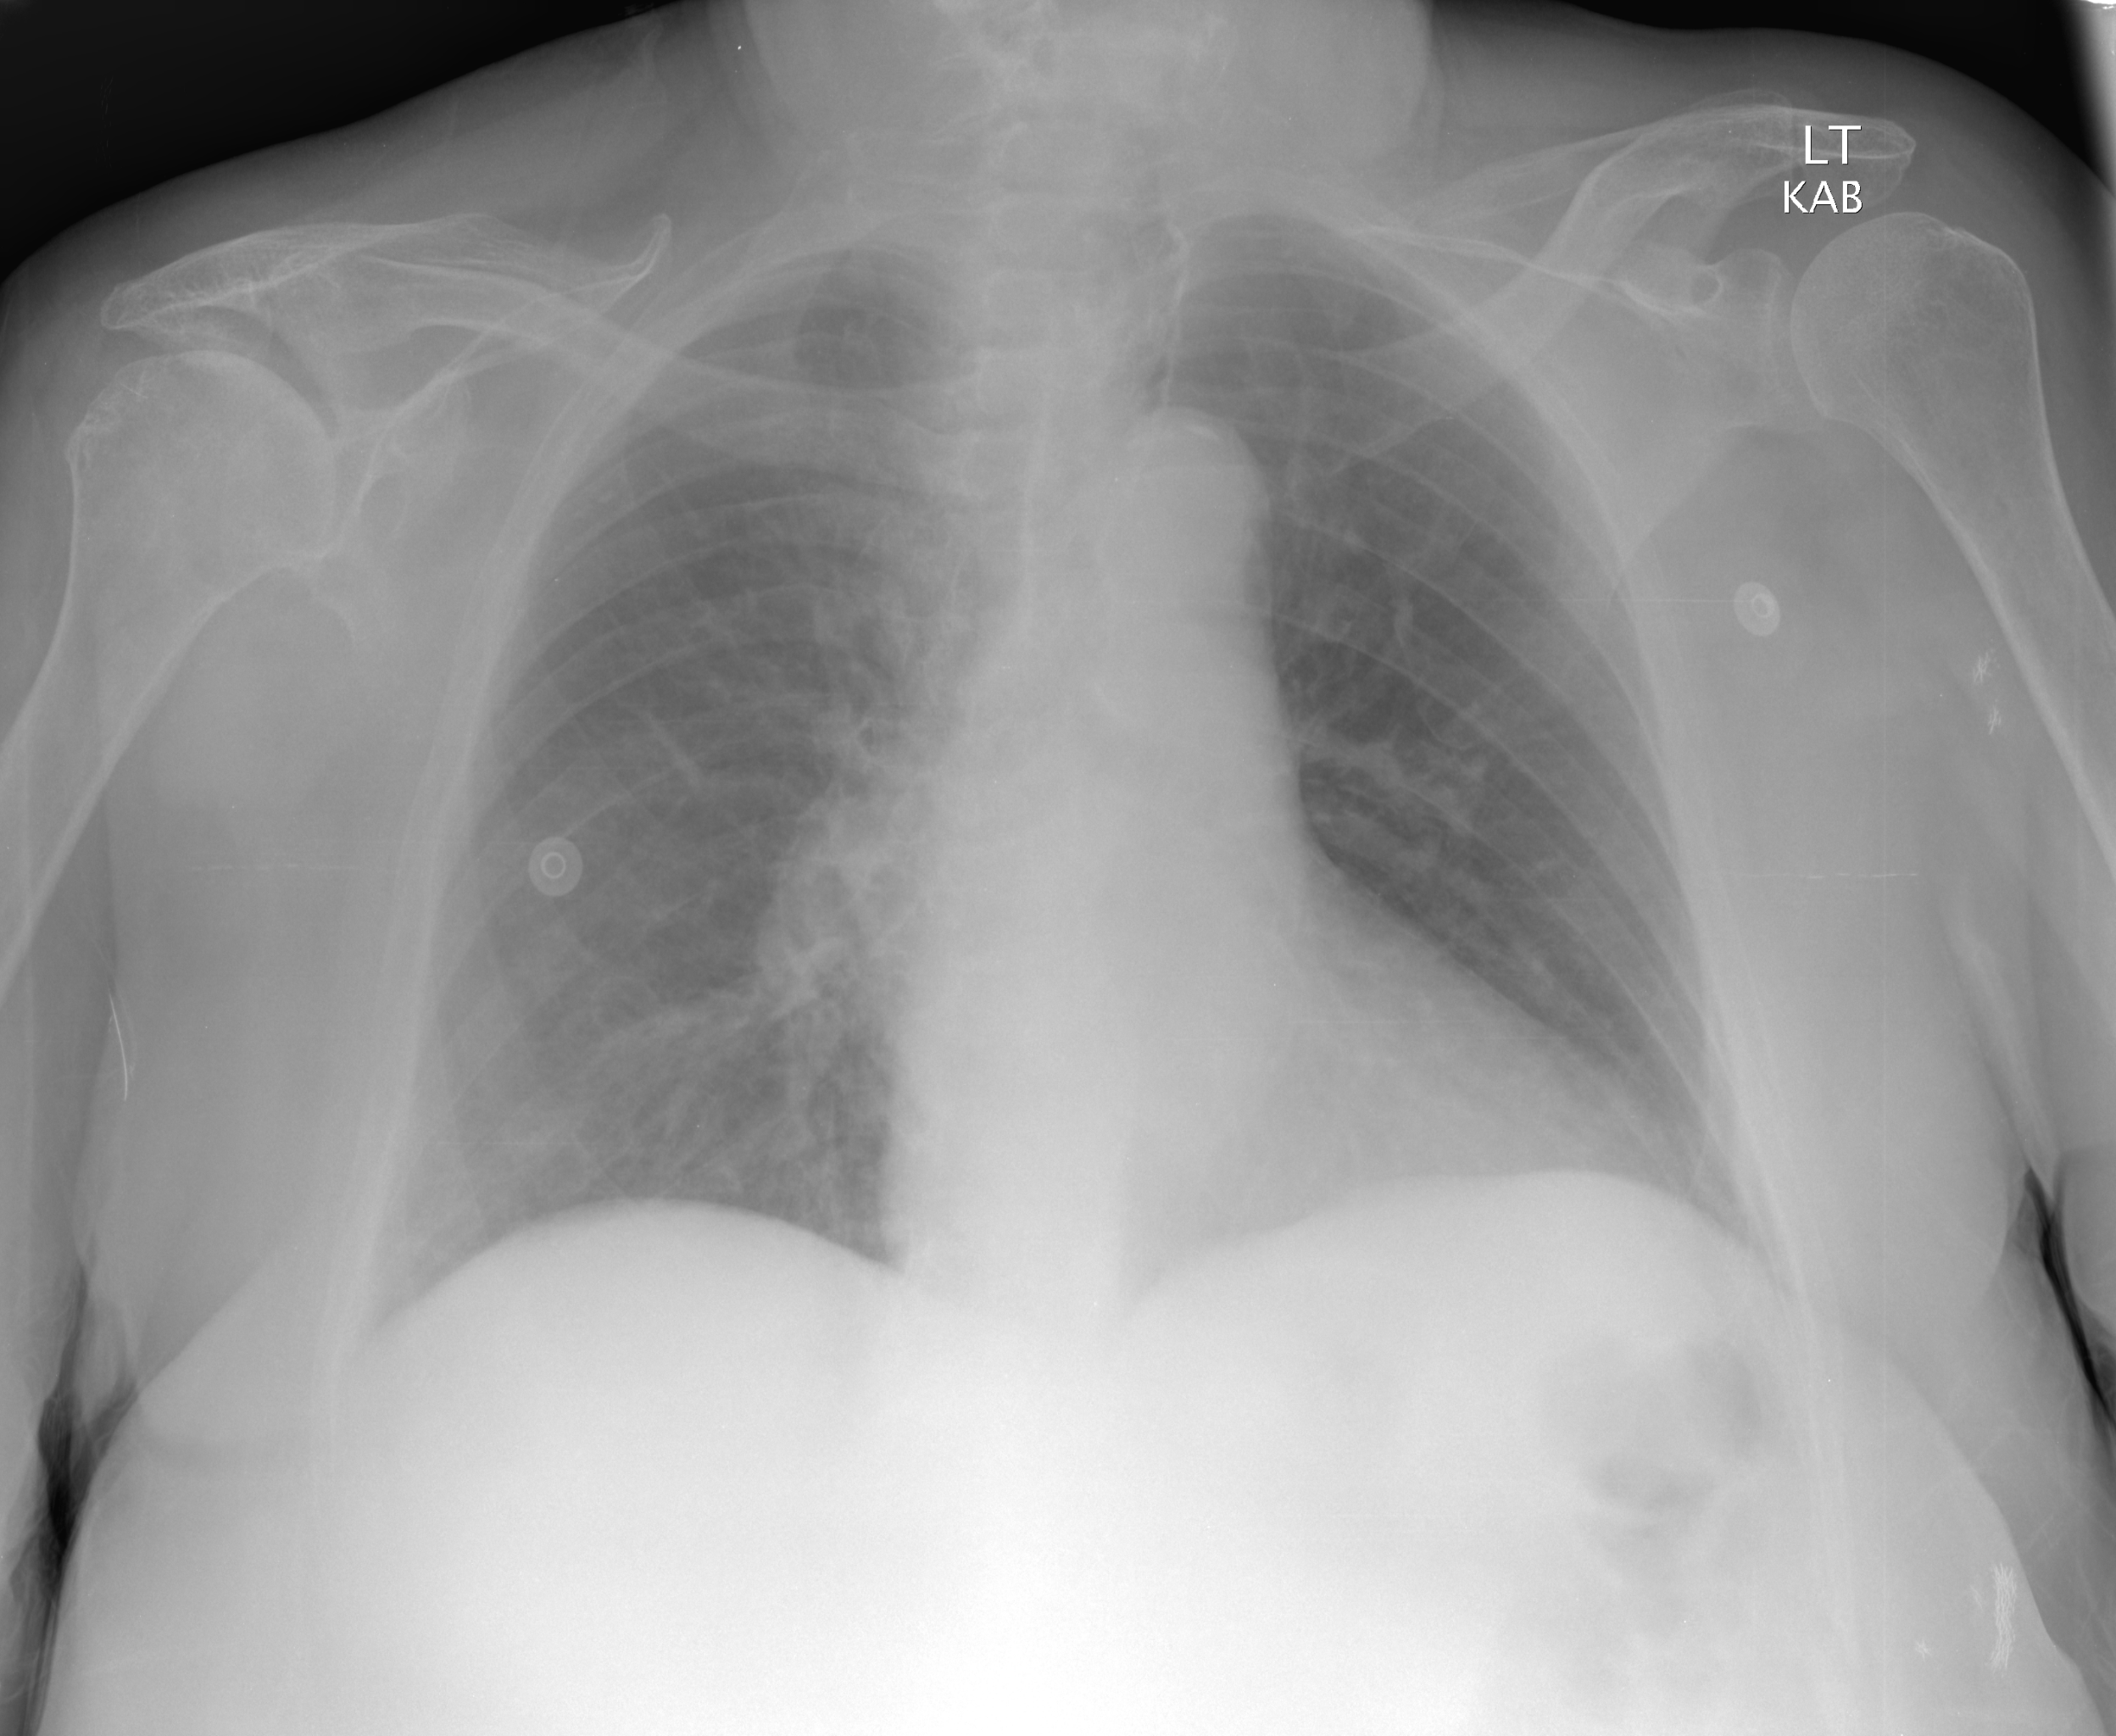

In [6]:
dataset = OpenIDataset(CFG["data_dir"], seed=CFG["seed"], frontal_only=CFG["frontal_only"])
train_split = dataset.get_split("train")
test_split = dataset.get_split("test")
full_train_size = len(train_split)

if CFG.get("max_train_samples"):
    train_split = train_split[: CFG["max_train_samples"]]

print(f"Total samples: {len(dataset)}")
print(f"Train: {len(train_split)} (of {full_train_size} available, capped by max_train_samples)  |  Test: {len(test_split)}")
print(f"Planned SFT steps: {len(train_split) * CFG['num_train_epochs']} ({len(train_split)} samples x {CFG['num_train_epochs']} epochs)")

sample = test_split[0]
print(f"\nSample ID: {sample['id']}")
print(f"Report:\n{sample['report'][:300]}...")
load_image(sample)

## Step 5 - LoRA and QLoRA 

In [7]:
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,   # T4 = Turing, no native bf16 - see note above
    bnb_4bit_use_double_quant=True,
)

base_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    CFG["model_id"],
    quantization_config=bnb_config,
    torch_dtype=torch.float16,
    device_map="auto",
)
processor = AutoProcessor.from_pretrained(
    CFG["model_id"],
    min_pixels=CFG["min_pixels"],
    max_pixels=CFG["max_pixels"],
)

base_model = prepare_model_for_kbit_training(base_model)

lora_config = LoraConfig(
    r=CFG["lora_r"],
    lora_alpha=CFG["lora_alpha"],
    lora_dropout=CFG["lora_dropout"],
    target_modules=CFG["lora_target_modules"],
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

trainable params: 47,589,376 || all params: 8,339,756,032 || trainable%: 0.5706


## Step 6 - A local inference helper

In [8]:
import time
from dataclasses import dataclass
from PIL import Image


@dataclass
class GenResult:
    report: str
    latency_s: float
    tokens_generated: int
    memory_mb: float


def resize_for_inference(image, max_side=CFG["max_image_side"]):
    """Downscale so the longest side is at most max_side px - bounds vision-token count and attention memory."""
    w, h = image.size
    if max(w, h) <= max_side:
        return image
    scale = max_side / max(w, h)
    return image.resize((int(w * scale), int(h * scale)), Image.LANCZOS)


def generate_report(model, processor, image, prompt, max_new_tokens=CFG["max_new_tokens"]):
    image = resize_for_inference(image)
    messages = [{
        "role": "user",
        "content": [{"type": "image", "image": image}, {"type": "text", "text": prompt}],
    }]
    text_input = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text_input], images=[image], return_tensors="pt").to(model.device)

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    latency_s = time.perf_counter() - t0
    memory_mb = torch.cuda.max_memory_allocated() / 1e6 if torch.cuda.is_available() else 0.0

    input_len = inputs["input_ids"].shape[1]
    new_ids = output_ids[:, input_len:]
    report = processor.batch_decode(new_ids, skip_special_tokens=True, clean_up_tokenization_spaces=True)[0]

    return GenResult(report=report.strip(), latency_s=latency_s, tokens_generated=int(new_ids.shape[1]), memory_mb=memory_mb)

## Step 7 - Prompt template and a quick sanity check

In [9]:
PROMPT = """You are an experienced radiologist. Examine the provided chest X-ray and write a structured radiology report.

Include exactly two sections:
- FINDINGS: a systematic description of the lungs, heart, mediastinum, pleura, bones, and soft tissues, noting any abnormality with its location and character.
- IMPRESSION: a concise summary of the clinically significant findings.

Output only plain-prose FINDINGS and IMPRESSION sentences - no extra headers, no bullet points, no patient name or date placeholders, no recommendations section, and no signature block. Use standard radiological terminology and remain objective."""

model.eval()
with model.disable_adapter():
    quick = generate_report(model, processor, load_image(sample), PROMPT)

print("=== GENERATED (adapter disabled == frozen base) ===")
print(quick.report)
print()
print(f"Latency: {quick.latency_s:.2f}s | Tokens: {quick.tokens_generated} | GPU mem: {quick.memory_mb:.0f} MB")
print()
print("=== GROUND TRUTH ===")
print(sample["report"])

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


=== GENERATED (adapter disabled == frozen base) ===
FINDINGS: The lung fields demonstrate increased interstitial markings bilaterally, particularly in the lower zones, suggestive of possible pulmonary edema or interstitial lung disease. The heart size appears within normal limits. The mediastinum is unremarkable for masses or lymphadenopathy. There are no obvious pleural effusions noted. The bony structures appear intact without evidence of fractures or lytic/sclerotic lesions. Soft tissue densities are unremarkable.

IMPRESSION: Bilateral interstitial lung changes consistent with pulmonary edema or interstitial lung disease. No acute cardiomegaly or pleural effusion identified. Bony structures are intact. Further clinical correlation recommended for definitive diagnosis.

Latency: 16.10s | Tokens: 143 | GPU mem: 3041 MB

=== GROUND TRUTH ===
FINDINGS: The heart size and mediastinal contours appear within normal limits. Atherosclerotic calcification of the aorta. No focal airspace cons

## Step 8 - Zero-shot baseline evaluation

In [10]:
import random
from contextlib import nullcontext
from tqdm.auto import tqdm

rng = random.Random(CFG["seed"])
indices = list(range(len(test_split)))
rng.shuffle(indices)
eval_indices = indices[:CFG["num_eval_samples"]]
eval_samples = [test_split[i] for i in eval_indices]
print(f"Evaluating on {len(eval_samples)} held-out test cases (seed={CFG['seed']}).")


def run_evaluation(model, processor, samples, prompt, tag, disable_adapter=False):
    records = []
    ctx = model.disable_adapter() if disable_adapter else nullcontext()
    with ctx:
        for s in tqdm(samples, desc=tag, unit="sample"):
            r = generate_report(model, processor, load_image(s), prompt)
            records.append({
                "id": s["id"],
                "ground_truth": s["report"],
                "prediction": r.report,
                "latency_s": r.latency_s,
                "tokens_generated": r.tokens_generated,
                "memory_mb": r.memory_mb,
            })
    return records


model.eval()
baseline_records = run_evaluation(model, processor, eval_samples, PROMPT, "zero-shot baseline", disable_adapter=True)
print(f"Collected {len(baseline_records)} zero-shot predictions.")

Evaluating on 100 held-out test cases (seed=42).


zero-shot baseline:   0%|          | 0/100 [00:00<?, ?sample/s]

Collected 100 zero-shot predictions.


## Step 9 - NLP metrics

In [11]:
def compute_text_metrics(predictions, references):
    import evaluate

    scores = {}

    bleu = evaluate.load("sacrebleu")
    bleu_res = bleu.compute(predictions=predictions, references=[[r] for r in references])
    scores["bleu"] = round(bleu_res["score"] / 100.0, 4)

    rouge = evaluate.load("rouge")
    rouge_res = rouge.compute(predictions=predictions, references=references)
    scores.update({k: round(float(v), 4) for k, v in rouge_res.items()})

    meteor = evaluate.load("meteor")
    meteor_res = meteor.compute(predictions=predictions, references=references)
    scores["meteor"] = round(float(meteor_res["meteor"]), 4)

    bertscore = evaluate.load("bertscore")
    bs_res = bertscore.compute(
        predictions=predictions,
        references=references,
        model_type=CFG["bertscore_model"],
        device="cuda" if torch.cuda.is_available() else "cpu",
    )
    scores["bertscore_f1"] = round(sum(bs_res["f1"]) / len(bs_res["f1"]), 4)

    try:
        from pycocoevalcap.cider.cider import Cider
        gts = {i: [r] for i, r in enumerate(references)}
        res = {i: [p] for i, p in enumerate(predictions)}
        cider_score, _ = Cider().compute_score(gts, res)
        scores["cider"] = round(float(cider_score), 4)
    except ImportError:
        scores["cider"] = 0.0

    return scores


baseline_preds = [r["prediction"] for r in baseline_records]
baseline_refs = [r["ground_truth"] for r in baseline_records]
baseline_scores = compute_text_metrics(baseline_preds, baseline_refs)
baseline_scores

[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'bleu': 0.0476,
 'rouge1': 0.273,
 'rouge2': 0.07,
 'rougeL': 0.182,
 'rougeLsum': 0.184,
 'meteor': 0.3822,
 'bertscore_f1': 0.862,
 'cider': 0.0016}

## Step 10 - Building the supervised fine-tuning dataset

In [12]:
class SFTDataset(torch.utils.data.Dataset):
    def __init__(self, samples, processor, prompt, max_side=CFG["max_image_side"]):
        self.samples = samples
        self.processor = processor
        self.prompt = prompt
        self.max_side = max_side

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        image = resize_for_inference(load_image(s), self.max_side)

        messages = [
            {"role": "user", "content": [{"type": "image", "image": image}, {"type": "text", "text": self.prompt}]},
            {"role": "assistant", "content": [{"type": "text", "text": s["report"]}]},
        ]
        full_text = self.processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
        prompt_text = self.processor.apply_chat_template(messages[:1], tokenize=False, add_generation_prompt=True)

        full = self.processor(text=[full_text], images=[image], return_tensors="pt")
        prompt_ids = self.processor.tokenizer(prompt_text, return_tensors="pt")["input_ids"]

        input_ids = full["input_ids"][0]
        labels = input_ids.clone()
        labels[: prompt_ids.shape[1]] = -100   # loss only on the assistant's report tokens

        item = {"input_ids": input_ids, "attention_mask": full["attention_mask"][0], "labels": labels}
        for key in ("pixel_values", "image_grid_thw"):
            if key in full:
                item[key] = full[key]
        return item


def sft_collate_fn(batch):
    pad_id = processor.tokenizer.pad_token_id
    if pad_id is None:
        pad_id = processor.tokenizer.eos_token_id

    max_len = max(len(b["input_ids"]) for b in batch)
    input_ids, attention_mask, labels = [], [], []
    for b in batch:
        pad_len = max_len - len(b["input_ids"])
        input_ids.append(torch.cat([b["input_ids"], torch.full((pad_len,), pad_id, dtype=torch.long)]))
        attention_mask.append(torch.cat([b["attention_mask"], torch.zeros(pad_len, dtype=torch.long)]))
        labels.append(torch.cat([b["labels"], torch.full((pad_len,), -100, dtype=torch.long)]))

    out = {
        "input_ids": torch.stack(input_ids),
        "attention_mask": torch.stack(attention_mask),
        "labels": torch.stack(labels),
    }
    for key in ("pixel_values", "image_grid_thw"):
        if key in batch[0]:
            out[key] = torch.cat([b[key] for b in batch], dim=0)
    return out


train_dataset = SFTDataset(train_split, processor, PROMPT)
print(f"SFT training examples: {len(train_dataset)}")

SFT training examples: 800


## Step 11 - Fine-tuning

In [13]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir=f"{CFG['output_dir']}/checkpoints",
    per_device_train_batch_size=CFG["train_batch_size"],
    gradient_accumulation_steps=CFG["grad_accum_steps"],
    num_train_epochs=CFG["num_train_epochs"],
    learning_rate=CFG["learning_rate"],
    optim="paged_adamw_8bit",
    gradient_checkpointing=True,
    fp16=True,                 # matches the T4's native precision (see the QLoRA note above)
    logging_steps=CFG["logging_steps"],
    save_strategy="no",
    report_to=[],
    remove_unused_columns=False,
    seed=CFG["seed"],
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    data_collator=sft_collate_fn,
)

train_result = trainer.train()

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Step,Training Loss
5,17.610405
10,16.133804
15,9.112463
20,6.875707
25,6.225843
30,6.135056
35,6.121670
40,6.019431
45,6.065574
50,6.028526


### Training loss curve

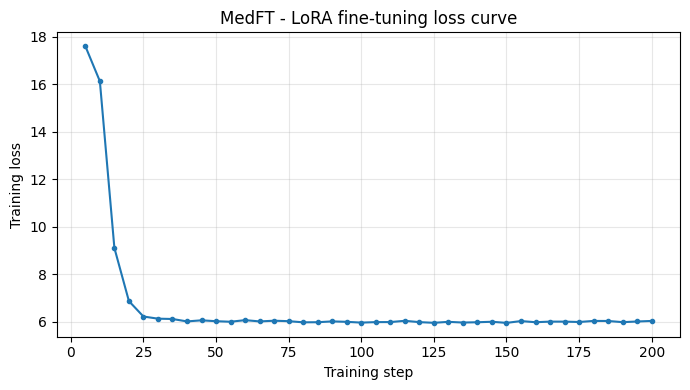

In [14]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
steps = [h["step"] for h in log_history if "loss" in h]
losses = [h["loss"] for h in log_history if "loss" in h]

plt.figure(figsize=(7, 4))
plt.plot(steps, losses, marker="o", markersize=3)
plt.xlabel("Training step")
plt.ylabel("Training loss")
plt.title("MedFT - LoRA fine-tuning loss curve")
plt.grid(alpha=0.3)
plt.tight_layout()

plots_dir = Path(CFG["output_dir"]) / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(plots_dir / "training_loss_curve.png", dpi=150)
plt.show()

## Step 12 - Save the LoRA adapter

In [15]:
adapter_dir = Path(CFG["output_dir"]) / "adapters" / "qwen2_5_vl_lora_openi"
adapter_dir.mkdir(parents=True, exist_ok=True)

model.save_pretrained(str(adapter_dir))
processor.save_pretrained(str(adapter_dir))

size_mb = sum(f.stat().st_size for f in adapter_dir.rglob("*") if f.is_file()) / 1e6
print(f"Adapter saved to {adapter_dir}  ({size_mb:.1f} MB)")

Adapter saved to /kaggle/working/outputs/adapters/qwen2_5_vl_lora_openi  (201.9 MB)


## Step 13 - Fine-tuned evaluation

In [16]:
model.eval()
finetuned_records = run_evaluation(model, processor, eval_samples, PROMPT, "fine-tuned (LoRA)", disable_adapter=False)

finetuned_preds = [r["prediction"] for r in finetuned_records]
finetuned_refs = [r["ground_truth"] for r in finetuned_records]
finetuned_scores = compute_text_metrics(finetuned_preds, finetuned_refs)
finetuned_scores

fine-tuned (LoRA):   0%|          | 0/100 [00:00<?, ?sample/s]

[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'bleu': 0.141,
 'rouge1': 0.4286,
 'rouge2': 0.1664,
 'rougeL': 0.3318,
 'rougeLsum': 0.333,
 'meteor': 0.3927,
 'bertscore_f1': 0.8949,
 'cider': 0.2048}

## Step 14 - Before vs. after: the headline comparison

In [17]:
import pandas as pd


def engineering_stats(records):
    lat = [r["latency_s"] for r in records]
    tok = [r["tokens_generated"] for r in records]
    mem = [r["memory_mb"] for r in records]
    return {
        "avg_latency_s": round(sum(lat) / len(lat), 4),
        "avg_tokens": round(sum(tok) / len(tok), 2),
        "avg_memory_mb": round(sum(mem) / len(mem), 2),
    }


comparison_df = pd.DataFrame([
    {"stage": "zero-shot (base)", **baseline_scores, **engineering_stats(baseline_records)},
    {"stage": "fine-tuned (LoRA)", **finetuned_scores, **engineering_stats(finetuned_records)},
])

tables_dir = Path(CFG["output_dir"]) / "tables"
tables_dir.mkdir(parents=True, exist_ok=True)
comparison_df.to_csv(tables_dir / "before_after_metrics.csv", index=False)

comparison_df

,stage,bleu,rouge1,rouge2,rougeL,rougeLsum,meteor,bertscore_f1,cider,avg_latency_s,avg_tokens,avg_memory_mb
0,zero-shot (base),0.0476,0.2730,0.0700,0.1820,0.184,0.3822,0.8620,0.0016,13.5418,137.06,3039.71
1,fine-tuned (LoRA),0.1410,0.4286,0.1664,0.3318,0.333,0.3927,0.8949,0.2048,9.1575,56.18,4151.92


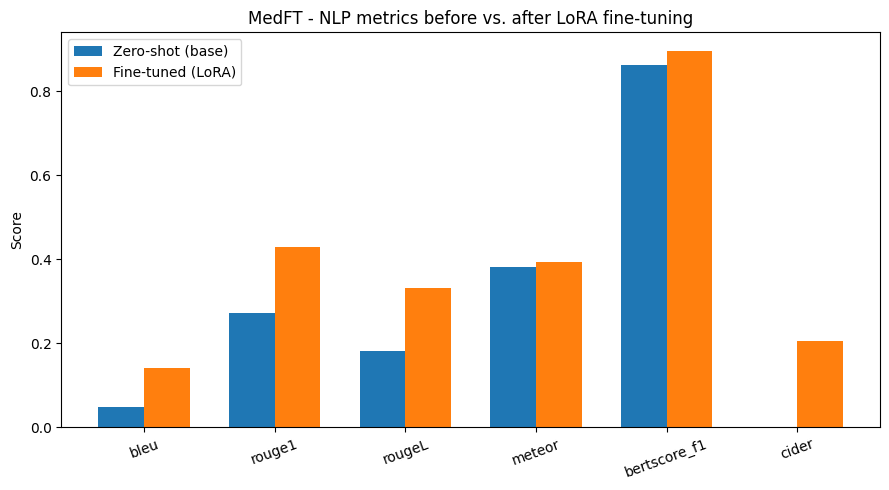

In [18]:
import numpy as np

metrics_to_plot = ["bleu", "rouge1", "rougeL", "meteor", "bertscore_f1", "cider"]
x = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width / 2, [baseline_scores.get(m, 0) for m in metrics_to_plot], width, label="Zero-shot (base)")
ax.bar(x + width / 2, [finetuned_scores.get(m, 0) for m in metrics_to_plot], width, label="Fine-tuned (LoRA)")
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, rotation=20)
ax.set_ylabel("Score")
ax.set_title("MedFT - NLP metrics before vs. after LoRA fine-tuning")
ax.legend()
fig.tight_layout()
fig.savefig(plots_dir / "before_after_metrics.png", dpi=150)
plt.show()

## Step 15 - Qualitative comparison

In [19]:
qual_positions = random.Random(CFG["seed"]).sample(range(len(baseline_records)), min(5, len(baseline_records)))

for i in qual_positions:
    b, f = baseline_records[i], finetuned_records[i]
    assert b["id"] == f["id"]
    print("=" * 100)
    print(f"CASE {b['id']}")
    print("-" * 100)
    print("GROUND TRUTH:")
    print(b["ground_truth"])
    print()
    print("ZERO-SHOT:")
    print(b["prediction"])
    print()
    print("FINE-TUNED:")
    print(f["prediction"])
    print()

CASE 1534_1534_IM-0345-4004.dcm
----------------------------------------------------------------------------------------------------
GROUND TRUTH:
FINDINGS: The cardiomediastinal silhouette is normal in size and contour. Aortic atherosclerosis. Hyperexpanded lungs. XXXX right perihilar/midlung density. Streaky bibasilar opacities, as well. Left upper lobe nodular opacity (anterior first rib interspace) may be exaggerated by overlapping bone silhouettes. Grossly similar midthoracic vertebral XXXX fracture. IMPRESSION: 1. No focal air space consolidation. 2. Nodular opacity at the left apex may be exaggerated by overlapping bone silhouettes. XXXX chest may provide further evaluation, if warranted.

ZERO-SHOT:
FINDINGS: The lung fields demonstrate increased interstitial markings bilaterally, particularly in the lower zones, suggestive of possible pulmonary edema or interstitial lung disease. The heart size appears within normal limits. The mediastinum is unremarkable for masses or lymphad

## Step 16 - Latency and memory: what the adapter costs at inference

In [20]:
engineering_df = pd.DataFrame([
    {"stage": "zero-shot (base)", **engineering_stats(baseline_records)},
    {"stage": "fine-tuned (LoRA, adapter active)", **engineering_stats(finetuned_records)},
])
engineering_df

,stage,avg_latency_s,avg_tokens,avg_memory_mb
0,zero-shot (base),13.5418,137.06,3039.71
1,"fine-tuned (LoRA, adapter active)",9.1575,56.18,4151.92
